In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv('health_data.csv')


In [14]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [15]:
df.isnull().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [16]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


In [17]:
df.duplicated().sum()


np.int64(0)

# Target Variable Analysis

In [18]:
df['Heart Disease'].value_counts()

Heart Disease
Absence     150
Presence    120
Name: count, dtype: int64

Visualization:

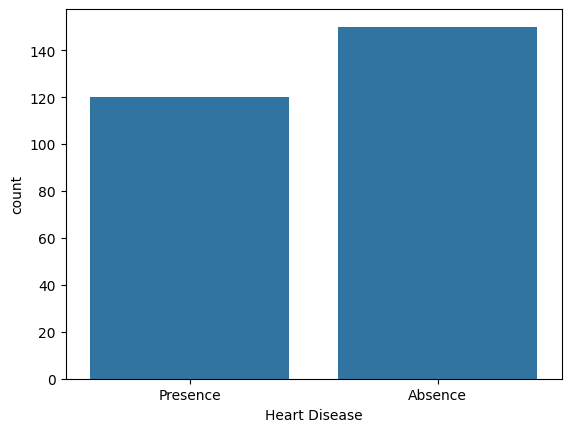

In [19]:
sns.countplot(x='Heart Disease', data=df)
plt.show()

# Numerical Feature Analysis

Numerical columns:

In [21]:
num_cols = [
    'Age', 'BP', 'Cholesterol',
    'Max HR', 'ST depression'
]

# Histograms

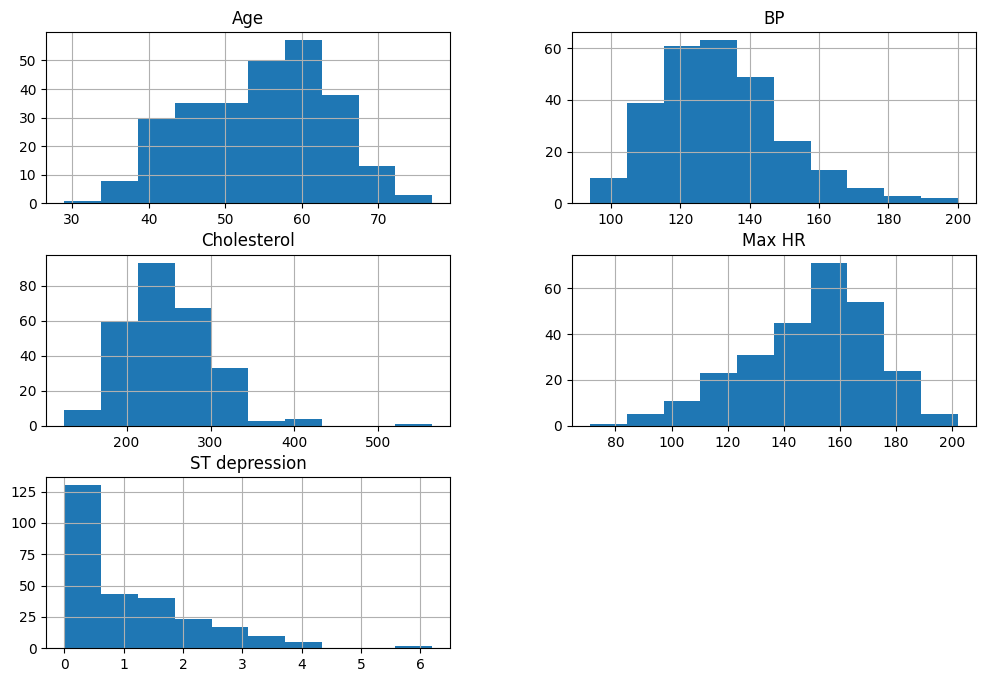

In [23]:
df[num_cols].hist(figsize=(12,8))
plt.show()

# Boxplots

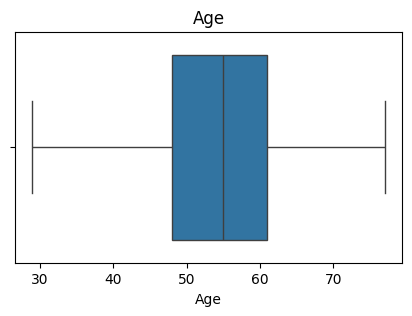

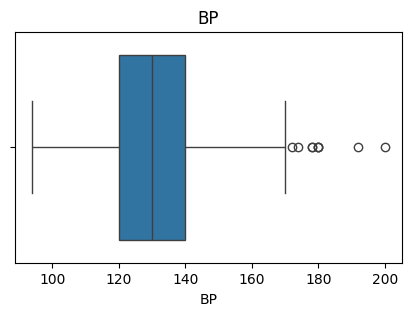

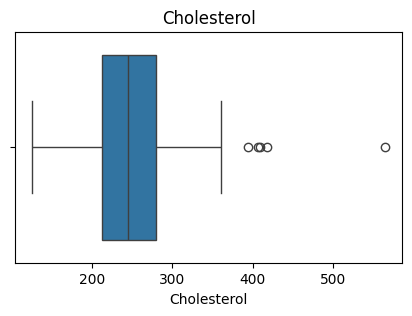

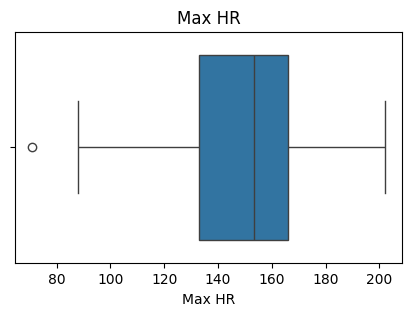

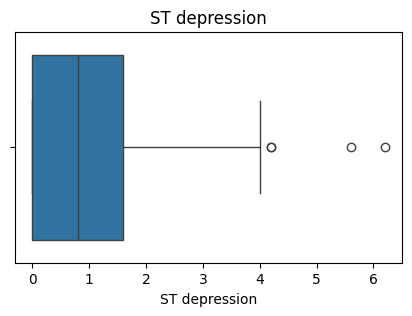

In [24]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

# Categorical Feature Analysis

Categorical columns:

In [25]:
cat_cols = [
    'Sex',
    'Chest pain type',
    'FBS over 120',
    'EKG results',
    'Exercise angina',
    'Slope of ST',
    'Number of vessels fluro',
    'Thallium'
]

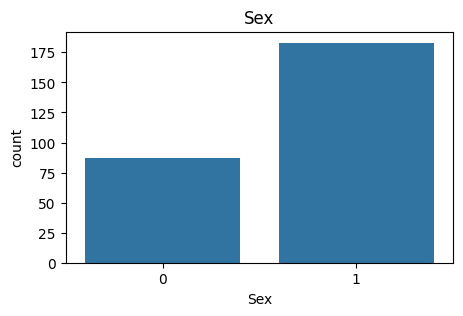

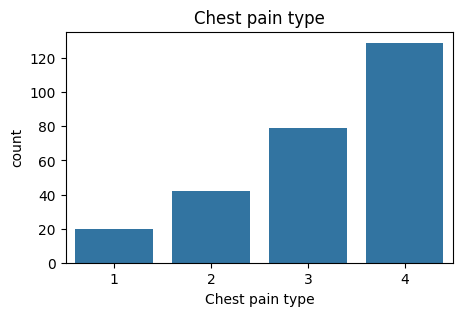

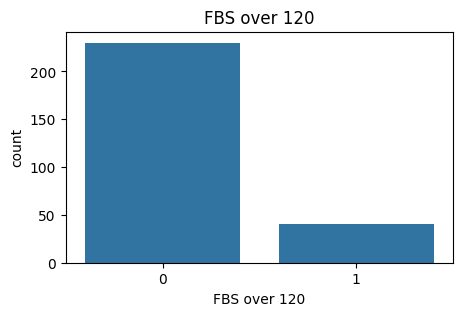

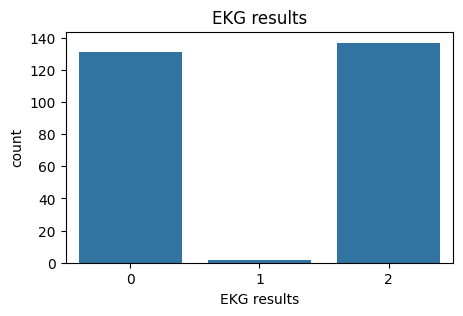

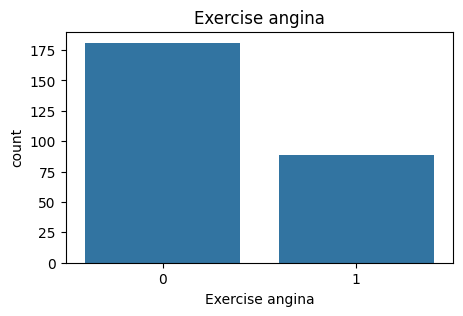

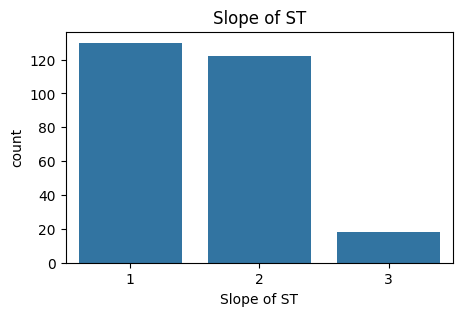

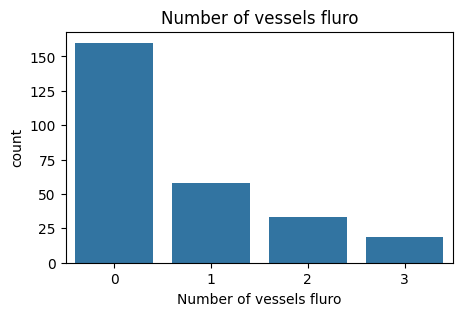

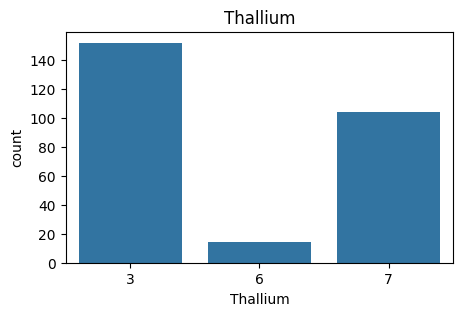

In [26]:
for col in cat_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(x=col, data=df)
    plt.title(col)
    plt.show()

# Feature vs Target Analysis

Age vs Heart Disease

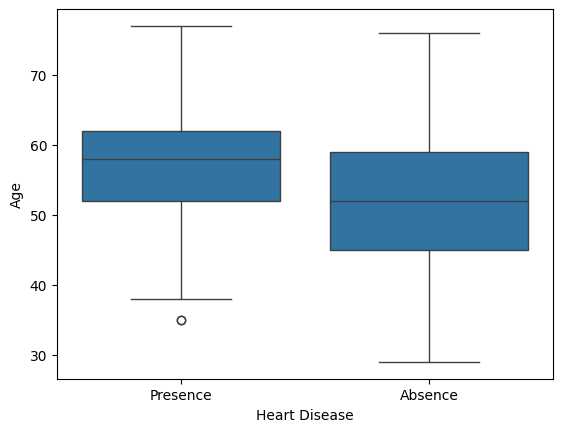

In [27]:
sns.boxplot(x='Heart Disease', y='Age', data=df)
plt.show()

Cholesterol vs Heart Disease

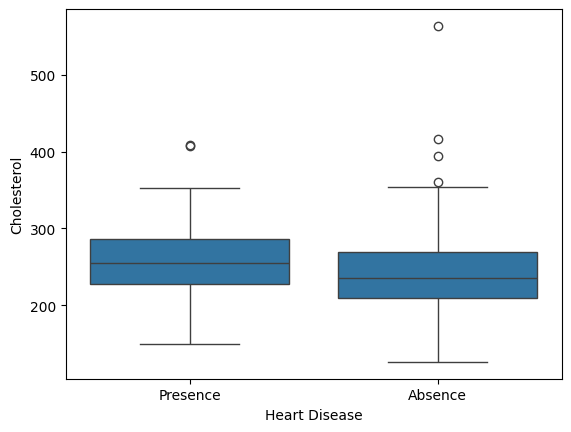

In [28]:
sns.boxplot(x='Heart Disease', y='Cholesterol', data=df)
plt.show()

Max HR vs Heart Disease

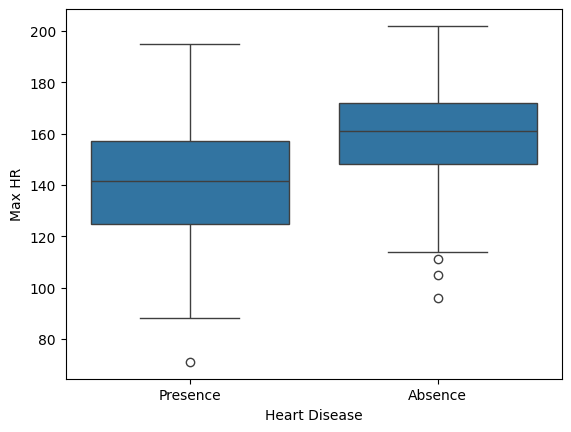

In [29]:
sns.boxplot(x='Heart Disease', y='Max HR', data=df)
plt.show()

Sex vs Heart Disease

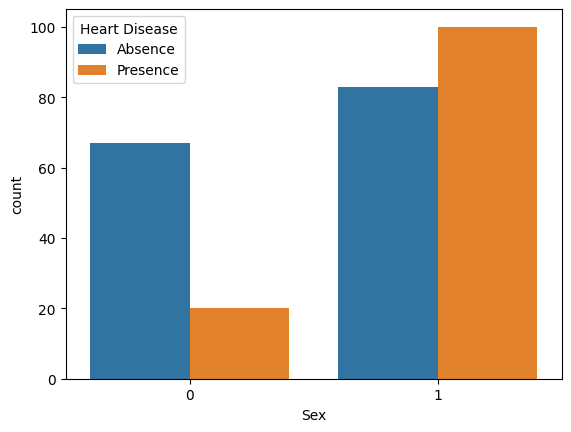

In [30]:
sns.countplot(x='Sex', hue='Heart Disease', data=df)
plt.show()

Chest Pain Type vs Heart Disease

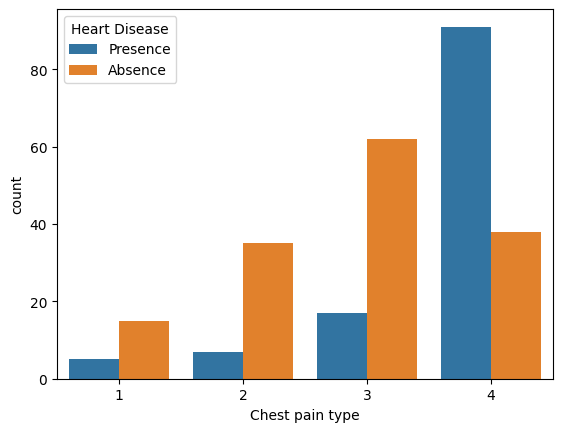

In [31]:
sns.countplot(x='Chest pain type', hue='Heart Disease', data=df)
plt.show()

# Correlation Analysis

First encode target:

In [32]:
df['Heart Disease'] = df['Heart Disease'].map({
    'Absence': 0,
    'Presence': 1
})

Correlation Heatmap:

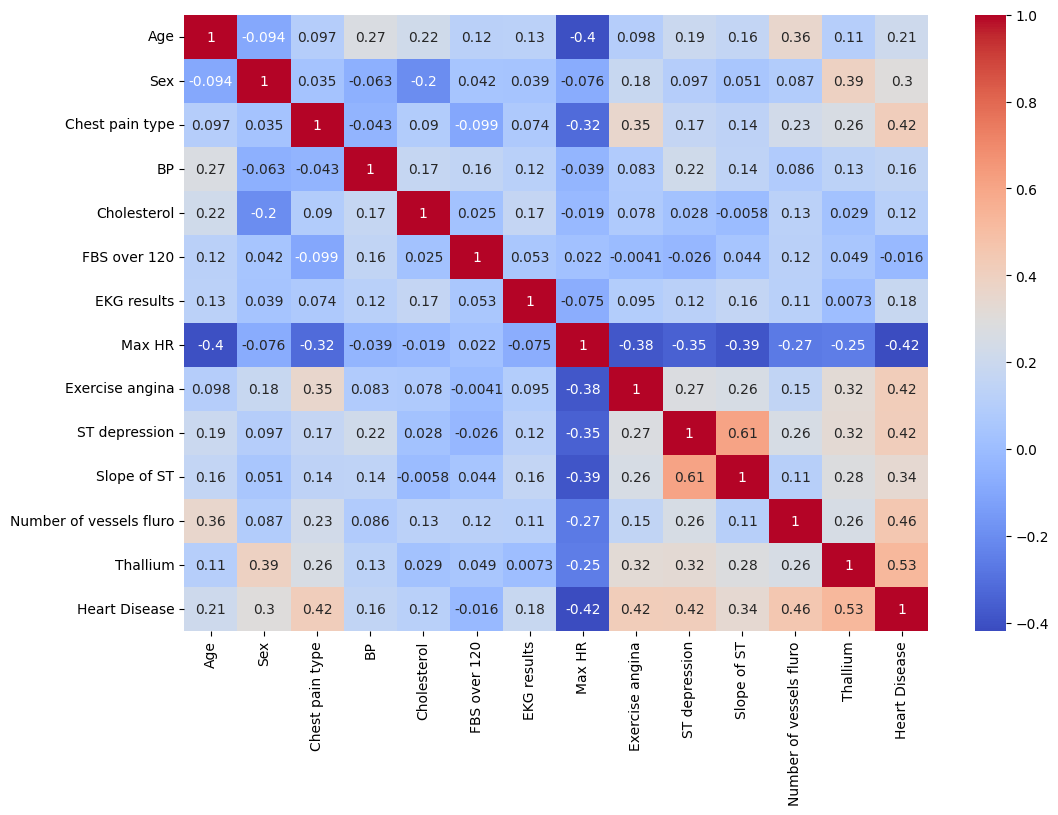

In [33]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')
plt.show()

# Heart Disease Percentage by Category

In [34]:
pd.crosstab(
    df['Chest pain type'],
    df['Heart Disease'],
    normalize='index'
)*100

Heart Disease,0,1
Chest pain type,,
1,75.000000,25.000000
2,83.333333,16.666667
3,78.481013,21.518987
4,29.457364,70.542636


# Pairplot

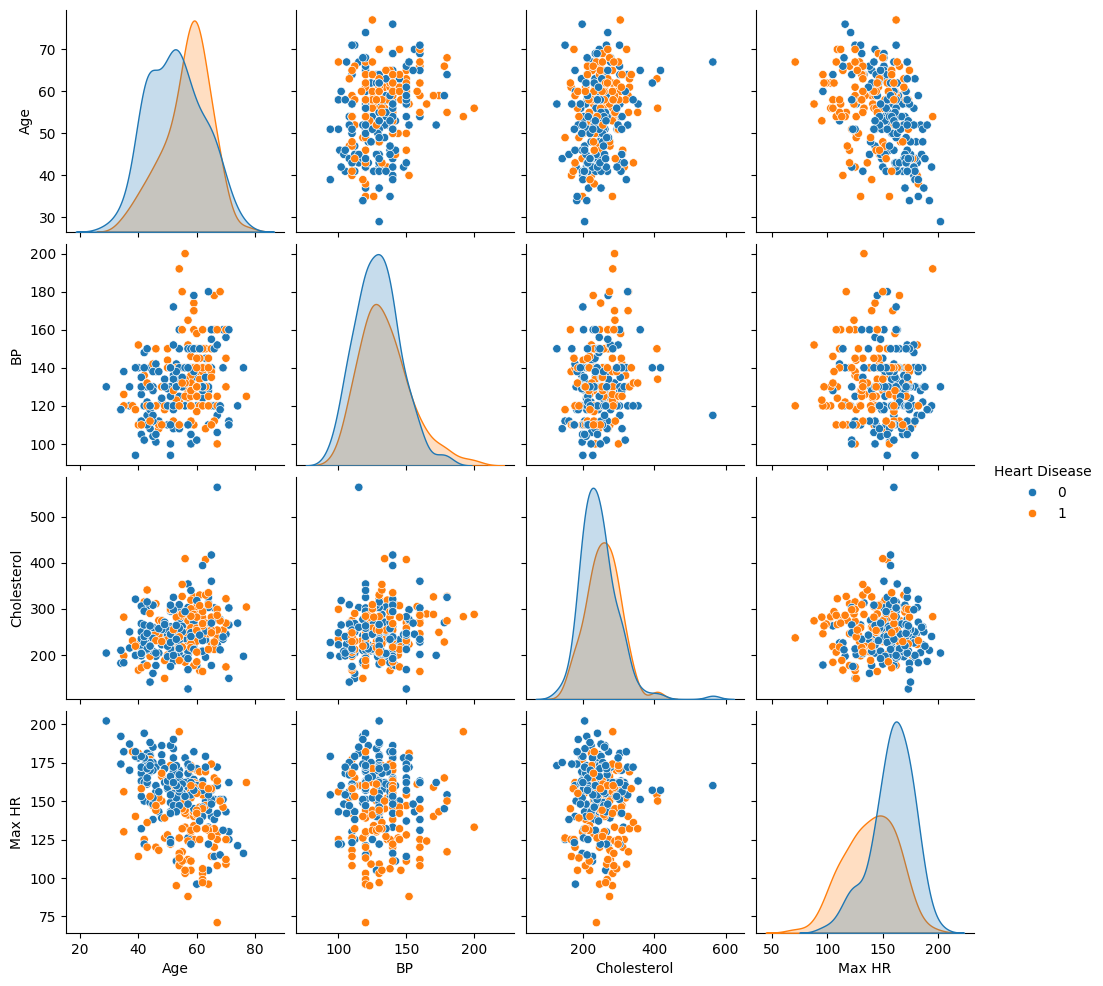

In [35]:
sns.pairplot(
    df,
    hue='Heart Disease',
    vars=['Age','BP','Cholesterol','Max HR']
)
plt.show()

# Outlier Detection

In [36]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)}")

Age: 0
BP: 9
Cholesterol: 5
Max HR: 1
ST depression: 4
